### Import Libaries and Groq

In [1]:
import os
from groq import Groq
from dotenv import load_dotenv
load_dotenv()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv()

print("Libraries loaded ✅")
client = Groq(api_key=os.getenv('GROQ_API_KEY'))

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{
        "role": "user",
        "content": "In one sentence, what is data analytics?"
    }]
)

print(response.choices[0].message.content)

Libraries loaded ✅
Data analytics is the process of examining and interpreting complex data sets to extract insights, patterns, and meaningful information that can inform business decisions, solve problems, or identify opportunities.


## load dataset 

In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"

df_raw = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv")
print(df_raw.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [3]:
print(df_raw.shape)
print(df_raw.dtypes)
print(df_raw.head(10))

(65457, 114)
ResponseId               int64
MainBranch              object
Age                     object
Employment              object
RemoteWork              object
                        ...   
JobSatPoints_11        float64
SurveyLength            object
SurveyEase              object
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
   ResponseId                                         MainBranch  \
0           1                     I am a developer by profession   
1           2                     I am a developer by profession   
2           3                     I am a developer by profession   
3           4                              I am learning to code   
4           5                     I am a developer by profession   
5           6                        I code primarily as a hobby   
6           7  I am not primarily a developer, but I write co...   
7           8                              I am learning to code   
8      

### understand data before cleaning

In [4]:
print("=== MISSING VALUES (top 20 columns) ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print(missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False).head(20))

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")


=== MISSING VALUES (top 20 columns) ===
                               count   pct
AINextMuch less integrated     64309  98.2
AINextLess integrated          63102  96.4
AINextNo change                52955  80.9
AINextMuch more integrated     52018  79.5
EmbeddedAdmired                48718  74.4
EmbeddedWantToWorkWith         47851  73.1
EmbeddedHaveWorkedWith         43236  66.1
ConvertedCompYearly            42020  64.2
AIToolNot interested in Using  41040  62.7
AINextMore integrated          41026  62.7
Knowledge_9                    37817  57.8
Frequency_3                    37742  57.7
Knowledge_7                    37674  57.6
ProfessionalTech               37689  57.6
Knowledge_8                    37694  57.6
Knowledge_6                    37588  57.4
Knowledge_5                    37572  57.4
Knowledge_2                    37431  57.2
Knowledge_4                    37422  57.2
Knowledge_3                    37357  57.1

=== DUPLICATES ===
Duplicate rows: 20


### API call

In [5]:
pip install requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import requests

# Make a GET request to fetch the IBM dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"

response = requests.get(url)

print(f"Status code: {response.status_code}")
print(f"Content type: {response.headers['Content-Type']}")
print(f"Data size: {len(response.content):,} bytes")

Status code: 200
Content type: text/csv
Data size: 154,822,125 bytes


### now convert to DataFrame

In [7]:
from io import StringIO

# Convert raw response to DataFrame
csv_data = response.content.decode('utf-8')
df_api = pd.read_csv(StringIO(csv_data))

print(f"Shape: {df_api.shape}")
print(f"First column: {df_api.columns[0]}")

Shape: (65457, 114)
First column: ResponseId


## drop duplicates

In [8]:
df_clean = df_raw.drop_duplicates()

print(f"Before : {df_raw.shape[0]:,} rows")
print(f"After : {df_clean.shape[0]:,} rows")
print(f"Removed : {df_raw.shape[0] - df_clean.shape[0]:,} duplicates")

Before : 65,457 rows
After : 65,437 rows
Removed : 20 duplicates


In [9]:
df_clean

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,65433,I am a developer by profession,18-24 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","On the job training;School (i.e., University, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,65435,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,65436,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [10]:
df_clean['LanguageHaveWorkedWith'].value_counts().head(10)

LanguageHaveWorkedWith
HTML/CSS;JavaScript;TypeScript           1002
Python                                    832
HTML/CSS;JavaScript;PHP;SQL               503
HTML/CSS;JavaScript                       452
C#                                        452
Python;SQL                                441
Java                                      424
C#;HTML/CSS;JavaScript;SQL;TypeScript     408
JavaScript;TypeScript                     402
C#;HTML/CSS;JavaScript;SQL                357
Name: count, dtype: int64

In [11]:
# Search all column names containing your keywords
keywords = ['Language', 'Database', 'Platform', 'Framework', 'Age', 
            'Country', 'Employment', 'Education', 'Learn', 'AI', 'artificial intelligence', 'ML', 'machine learning', 'Webframe']

for keyword in keywords:
    matches = [col for col in df_clean.columns if keyword in col]
    if matches:
        print(f"\n{keyword}:")
        for col in matches:
            print(f"  {col}")


Language:
  LanguageHaveWorkedWith
  LanguageWantToWorkWith
  LanguageAdmired

Database:
  DatabaseHaveWorkedWith
  DatabaseWantToWorkWith
  DatabaseAdmired

Platform:
  PlatformHaveWorkedWith
  PlatformWantToWorkWith
  PlatformAdmired

Age:
  Age

Country:
  Country

Employment:
  Employment

Learn:
  LearnCode
  LearnCodeOnline

AI:
  AISearchDevHaveWorkedWith
  AISearchDevWantToWorkWith
  AISearchDevAdmired
  AISelect
  AISent
  AIBen
  AIAcc
  AIComplex
  AIToolCurrently Using
  AIToolInterested in Using
  AIToolNot interested in Using
  AINextMuch more integrated
  AINextNo change
  AINextMore integrated
  AINextLess integrated
  AINextMuch less integrated
  AIThreat
  AIEthics
  AIChallenges

Webframe:
  WebframeHaveWorkedWith
  WebframeWantToWorkWith
  WebframeAdmired


In [12]:
# Define your relevant columns
relevant_cols = [
    # Current technology
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    
    # Desired/future technology
    'LanguageWantToWorkWith',
    'DatabaseWantToWorkWith',
    'PlatformWantToWorkWith',
    'WebframeWantToWorkWith',
    
    # Demographics
    'Age', 'Country', 'Employment', 'RemoteWork',
    
    # Learning
    'LearnCode', 'LearnCodeOnline',
    
    # AI
    'AISelect', 'AIToolCurrently Using',
    'AIToolInterested in Using',
    'AIBen', 'AIThreat'
]

# Select only those columns
df_focused = df_clean[relevant_cols]

print(f"Original: {df_clean.shape}")
print(f"Focused:  {df_focused.shape}")

Original: (65437, 114)
Focused:  (65437, 19)


In [13]:
df_focused.shape
df_focused.dtypes
df_focused.head()

,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,LanguageWantToWorkWith,DatabaseWantToWorkWith,PlatformWantToWorkWith,WebframeWantToWorkWith,Age,Country,Employment,RemoteWork,LearnCode,LearnCodeOnline,AISelect,AIToolCurrently Using,AIToolInterested in Using,AIBen,AIThreat
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Under 18 years old,United States of America,"Employed, full-time",Remote,Books / Physical media,NaN,Yes,NaN,NaN,Increase productivity,NaN
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Express;Htmx;Node.js;React;Remix,35-44 years old,United Kingdom of Great Britain and Northern I...,"Employed, full-time",Remote,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,"No, and I don't plan to",NaN,NaN,NaN,NaN
2,C#,Firebase Realtime Database,Google Cloud,ASP.NET CORE,C#,Firebase Realtime Database,Google Cloud,ASP.NET CORE,45-54 years old,United Kingdom of Great Britain and Northern I...,"Employed, full-time",Remote,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,"No, and I don't plan to",NaN,NaN,NaN,NaN
3,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,MongoDB;MySQL;PostgreSQL;SQLite,Amazon Web Services (AWS);Fly.io;Heroku,jQuery;Next.js;Node.js;React;WordPress,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,MongoDB;MySQL;PostgreSQL,Amazon Web Services (AWS);Vercel,jQuery;Next.js;Node.js;React,18-24 years old,Canada,"Student, full-time",NaN,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,Yes,Learning about a codebase;Project planning;Wri...,Testing code;Committing and reviewing code;Pre...,Increase productivity;Greater efficiency;Impro...,No
4,C++;HTML/CSS;JavaScript;Lua;Python;Rust,PostgreSQL;SQLite,NaN,NaN,C++;HTML/CSS;JavaScript;Lua;Python,PostgreSQL;SQLite,NaN,NaN,18-24 years old,Norway,"Student, full-time",NaN,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,"No, and I don't plan to",NaN,NaN,NaN,NaN


### missing values

In [14]:
missing = df_focused.isnull().sum()
missing_pct = (missing / len(df_focused) * 100).round(1)

print(pd.DataFrame({ 'missing': missing, 'pct': missing_pct}).sort_values('pct', ascending=False))

                           missing   pct
AIToolInterested in Using    34746  53.1
PlatformWantToWorkWith       30905  47.2
AIToolCurrently Using        30365  46.4
AIBen                        28543  43.6
WebframeWantToWorkWith       26902  41.1
PlatformHaveWorkedWith       23071  35.3
DatabaseWantToWorkWith       22879  35.0
AIThreat                     20748  31.7
WebframeHaveWorkedWith       20276  31.0
LearnCodeOnline              16200  24.8
DatabaseHaveWorkedWith       15183  23.2
RemoteWork                   10631  16.2
LanguageWantToWorkWith        9685  14.8
Country                       6507   9.9
LanguageHaveWorkedWith        5692   8.7
LearnCode                     4949   7.6
AISelect                      4530   6.9
Employment                       0   0.0
Age                              0   0.0


In [15]:
# Drop columns with more than 40% missing
df_focused = df_focused.dropna(thresh=int(len(df_focused) * 0.6), axis=1)

print(f"Columns remaining: {df_focused.shape[1]}")
print(f"Columns kept: {list(df_focused.columns)}")

Columns remaining: 14
Columns kept: ['LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseWantToWorkWith', 'Age', 'Country', 'Employment', 'RemoteWork', 'LearnCode', 'LearnCodeOnline', 'AISelect', 'AIThreat']


In [16]:
languages = df_focused["LanguageHaveWorkedWith"].dropna().str.split(";").explode()
print(languages.value_counts().head(15))

LanguageHaveWorkedWith
JavaScript                 37492
HTML/CSS                   31816
Python                     30719
SQL                        30682
TypeScript                 23150
Bash/Shell (all shells)    20412
Java                       18239
C#                         16318
C++                        13827
C                          12184
PHP                        10951
PowerShell                  8328
Go                          8103
Rust                        7559
Kotlin                      5665
Name: count, dtype: int64


In [17]:
languages_want = df_focused["LanguageWantToWorkWith"].dropna().str.split(";").explode()
print(languages_want.value_counts().head(15))

LanguageWantToWorkWith
Python                     25047
JavaScript                 23774
SQL                        22400
HTML/CSS                   20721
TypeScript                 20239
Rust                       17232
Go                         13837
Bash/Shell (all shells)    13744
C#                         12921
C++                        10873
Java                       10668
C                           8275
Kotlin                      7379
PHP                         5745
PowerShell                  4287
Name: count, dtype: int64


In [18]:
db_have = df_focused["DatabaseHaveWorkedWith"].dropna().str.split(";").explode()
db_want = df_focused["DatabaseWantToWorkWith"].dropna().str.split(";").explode()

print("=== Currently Using ===")
print(db_have.value_counts().head(10))

print("\n=== Want to Learn ===")
print(db_want.value_counts().head(10))

=== Currently Using ===
DatabaseHaveWorkedWith
PostgreSQL              25536
MySQL                   21099
SQLite                  17365
Microsoft SQL Server    13275
MongoDB                 13007
Redis                   10463
MariaDB                  8991
Elasticsearch            6533
Oracle                   5273
Dynamodb                 4138
Name: count, dtype: int64

=== Want to Learn ===
DatabaseWantToWorkWith
PostgreSQL              24005
SQLite                  13489
MySQL                   12269
MongoDB                 10982
Redis                   10847
Microsoft SQL Server     7905
Elasticsearch            6246
MariaDB                  5947
Dynamodb                 3503
Supabase                 2930
Name: count, dtype: int64


In [19]:
print(df_focused['AISelect'].value_counts())

AISelect
Yes                        37662
No, and I don't plan to    14837
No, but I plan to soon      8408
Name: count, dtype: int64


In [20]:
result = 37662 / 65437
percentage = result * 100
print(percentage)


57.554594495468926


In [21]:
import sys
import os

# Add your scripts folder to the path
sys.path.append(os.path.abspath('../Toolkit'))

# Import your toolkit
from chart_template import *
from cleaning_utils import *
from api_extract import *
# from db_connect import *
# from report_template import *


print("✅ Toolkit loaded successfully")

✅ Toolkit loaded successfully


In [22]:
import os
print(os.listdir('../Toolkit'))

['api_extract.py', 'chart_template.py', 'cleaning_utils.py', 'db_connect.py', 'gitignore.py', 'report_template.py', 'SQL_templates.sql', 'understand_data.py', '__pycache__']


### put messy columns in categories

In [23]:
def say_hello(name):
    return f"Hello {name}!"

say_hello("Julio")


'Hello Julio!'

- def         → "I'm defining a function"
- say_hello   → the function name
- (name)      → the input it accepts
- return      → what it gives back

In [24]:
def exploded_column(df, col_name): 
    return df[col_name].dropna().str.split(";").explode().value_counts()

In [25]:
# Languages currently used
lang_have = exploded_column(df_focused, 'LanguageHaveWorkedWith')

# Languages want to learn
lang_want = exploded_column(df_focused, 'LanguageWantToWorkWith')

# Databases currently used
db_have = exploded_column(df_focused, 'DatabaseHaveWorkedWith')

### add two columns

In [26]:
# Add missing columns
df_focused = df_clean[list(df_focused.columns) + ['PlatformWantToWorkWith', 'EdLevel']]

print(f"Columns now: {df_focused.shape[1]}")
print(list(df_focused.columns))

Columns now: 16
['LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseWantToWorkWith', 'Age', 'Country', 'Employment', 'RemoteWork', 'LearnCode', 'LearnCodeOnline', 'AISelect', 'AIThreat', 'PlatformWantToWorkWith', 'EdLevel']


In [27]:
df_new = pd.read_csv("C:\work_related\survey_data_updated_5.csv")

print(f"Old dataset: {df_clean.shape}")
print(f"New dataset: {df_new.shape}")
print(f"\nNew columns not in old:")
new_cols = set(df_new.columns) - set(df_clean.columns)
print(new_cols)

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\Jmero\AppData\Local\Temp\ipykernel_13496\4112147344.py:1: SyntaxWarning: invalid escape sequence '\w'
  df_new = pd.read_csv("C:\work_related\survey_data_updated_5.csv")


Old dataset: (65437, 114)
New dataset: (18845, 114)

New columns not in old:
set()


In [28]:
print("EdLevel" in df_new.columns)
print("PlatformWantToWorkWith" in df_new.columns)
print(df_new.isnull().sum().sort_values(ascending=False).head(10))

True
True
AINextMuch less integrated       18492
AINextLess integrated            18093
AINextNo change                  14468
AINextMuch more integrated       13676
EmbeddedAdmired                  13064
EmbeddedWantToWorkWith           12932
EmbeddedHaveWorkedWith           11943
AIToolNot interested in Using    10067
AINextMore integrated             9816
ConvertedCompYearly               9295
dtype: int64


In [29]:
df_raw_2 = df_new.copy()
profile(df_raw_2, 'IBM Capstone Dataset')


PROFILE: IBM Capstone Dataset
Shape:      18,845 rows  x  114 columns
Memory:     136.9 MB

--- DATA TYPES ---
ResponseId                          int64
MainBranch                         object
Age                                object
Employment                         object
RemoteWork                         object
Check                              object
CodingActivities                   object
EdLevel                            object
LearnCode                          object
LearnCodeOnline                    object
TechDoc                            object
YearsCode                          object
YearsCodePro                       object
DevType                            object
OrgSize                            object
PurchaseInfluence                  object
BuyNewTool                         object
BuildvsBuy                         object
TechEndorse                        object
Country                            object
Currency                           object
CompTo

In [30]:
df_raw_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18845 entries, 0 to 18844
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 16.4+ MB


In [31]:
print(f"rows: {df_raw_2.shape[0]:,}")
print(f"duplicate rows: {df_raw_2.duplicated().sum():,}")
df_raw_2.columns

rows: 18,845
duplicate rows: 0


Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)

## select relevant columns, names that we need. 

In [32]:
keywords_2 = ['Language', 'Database', 'Platform', 'Webframe', 
            'Age', 'Country', 'Employment', 'EdLevel', 'RemoteWork']

for keyword in keywords:
    matches = [col for col in df_raw_2.columns if keyword in col]
    if matches:
        print(f"\n{keyword}:")
        for col in matches:
            print(f"  {col}")


Language:
  LanguageHaveWorkedWith
  LanguageWantToWorkWith
  LanguageAdmired

Database:
  DatabaseHaveWorkedWith
  DatabaseWantToWorkWith
  DatabaseAdmired

Platform:
  PlatformHaveWorkedWith
  PlatformWantToWorkWith
  PlatformAdmired

Age:
  Age

Country:
  Country

Employment:
  Employment

Learn:
  LearnCode
  LearnCodeOnline

AI:
  AISearchDevHaveWorkedWith
  AISearchDevWantToWorkWith
  AISearchDevAdmired
  AISelect
  AISent
  AIBen
  AIAcc
  AIComplex
  AIToolCurrently Using
  AIToolInterested in Using
  AIToolNot interested in Using
  AINextMuch more integrated
  AINextNo change
  AINextMore integrated
  AINextLess integrated
  AINextMuch less integrated
  AIThreat
  AIEthics
  AIChallenges

Webframe:
  WebframeHaveWorkedWith
  WebframeWantToWorkWith
  WebframeAdmired


In [33]:
relevant_cols_2 = [
    # Dashboard 1 — Current Technology
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    
    # Dashboard 2 — Future Trends
    'LanguageWantToWorkWith',
    'DatabaseWantToWorkWith',
    'PlatformWantToWorkWith',
    'WebframeWantToWorkWith',
    
    # Dashboard 3 — Demographics
    'Age',
    'Country',
    'Employment',
    'EdLevel',
    'RemoteWork'
]

df_focused_2 = df_raw_2[relevant_cols_2]

print(f"Shape: {df_focused_2.shape}")
print(f"Columns: {list(df_focused_2.columns)}")

Shape: (18845, 13)
Columns: ['LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseWantToWorkWith', 'PlatformWantToWorkWith', 'WebframeWantToWorkWith', 'Age', 'Country', 'Employment', 'EdLevel', 'RemoteWork']


In [34]:
missing_2 = df_focused_2.isnull().sum()
missing_pct_2 = (missing_2 / len(df_focused_2) * 100).round(1)

print(pd.DataFrame({"missing": missing_2, 'pct': missing_pct_2}).sort_values('pct', ascending=False))




                        missing  pct
LanguageHaveWorkedWith        0  0.0
DatabaseHaveWorkedWith        0  0.0
PlatformHaveWorkedWith        0  0.0
WebframeHaveWorkedWith        0  0.0
LanguageWantToWorkWith        0  0.0
DatabaseWantToWorkWith        0  0.0
PlatformWantToWorkWith        0  0.0
WebframeWantToWorkWith        0  0.0
Age                           0  0.0
Country                       0  0.0
Employment                    0  0.0
EdLevel                       0  0.0
RemoteWork                    6  0.0


In [35]:
import os
os.makedirs('../reports', exist_ok=True)

# Dashboard 1 — Current Technology
lang_have = df_focused_2['LanguageHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
lang_have.columns = ['Language', 'Count']

db_have = df_focused_2['DatabaseHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
db_have.columns = ['Database', 'Count']

platform_have = df_focused_2['PlatformHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
platform_have.columns = ['Platform', 'Count']

webframe_have = df_focused_2['WebframeHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
webframe_have.columns = ['Webframe', 'Count']

# Save Dashboard 1 files
lang_have.to_csv('../reports/dash1_languages.csv', index=False)
db_have.to_csv('../reports/dash1_databases.csv', index=False)
platform_have.to_csv('../reports/dash1_platforms.csv', index=False)
webframe_have.to_csv('../reports/dash1_webframes.csv', index=False)

print("Dashboard 1 files saved ✅")
print(lang_have)

Dashboard 1 files saved ✅
                  Language  Count
0               JavaScript  14943
1                      SQL  12602
2                 HTML/CSS  12410
3               TypeScript  10709
4                   Python   9590
5  Bash/Shell (all shells)   7244
6                       C#   6340
7                     Java   5982
8                      PHP   4644
9               PowerShell   3438


In [36]:
# Dashboard 2 — Future Trends
lang_want = df_focused_2['LanguageWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
lang_want.columns = ['Language', 'Count']

db_want = df_focused_2['DatabaseWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
db_want.columns = ['Database', 'Count']

platform_want = df_focused_2['PlatformWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
platform_want.columns = ['Platform', 'Count']

webframe_want = df_focused_2['WebframeWantToWorkWith'].dropna().str.split(';').explode().value_counts().head(10).reset_index()
webframe_want.columns = ['Webframe', 'Count']

# Dashboard 3 — Demographics
age_dist = df_focused_2['Age'].value_counts().reset_index()
age_dist.columns = ['Age', 'Count']

country_dist = df_focused_2['Country'].value_counts().head(20).reset_index()
country_dist.columns = ['Country', 'Count']

edlevel_dist = df_focused_2['EdLevel'].value_counts().reset_index()
edlevel_dist.columns = ['EdLevel', 'Count']

# Save all files
lang_want.to_csv('../reports/dash2_languages.csv', index=False)
db_want.to_csv('../reports/dash2_databases.csv', index=False)
platform_want.to_csv('../reports/dash2_platforms.csv', index=False)
webframe_want.to_csv('../reports/dash2_webframes.csv', index=False)
age_dist.to_csv('../reports/dash3_age.csv', index=False)
country_dist.to_csv('../reports/dash3_country.csv', index=False)
edlevel_dist.to_csv('../reports/dash3_edlevel.csv', index=False)

print("All dashboard files saved ✅")

All dashboard files saved ✅


In [37]:
# Age grouped by Education Level
age_edlevel = df_focused_2.groupby(['Age', 'EdLevel']).size().reset_index(name='Count')
age_edlevel.to_csv('../reports/dash3_age_edlevel.csv', index=False)
print("Saved ✅")
print(age_edlevel.head(10))

Saved ✅
               Age                                            EdLevel  Count
0  18-24 years old                Associate degree (A.A., A.S., etc.)    132
1  18-24 years old       Bachelor's degree (B.A., B.S., B.Eng., etc.)   1468
2  18-24 years old    Master's degree (M.A., M.S., M.Eng., MBA, etc.)    299
3  18-24 years old                          Primary/elementary school     25
4  18-24 years old     Professional degree (JD, MD, Ph.D, Ed.D, etc.)     20
5  18-24 years old  Secondary school (e.g. American high school, G...    495
6  18-24 years old  Some college/university study without earning ...    496
7  18-24 years old                                     Something else     53
8  25-34 years old                Associate degree (A.A., A.S., etc.)    231
9  25-34 years old       Bachelor's degree (B.A., B.S., B.Eng., etc.)   3985


In [38]:
# Rename columns to be safe
age_edlevel = df_focused_2.groupby(['Age', 'EdLevel']).size().reset_index(name='Count')
age_edlevel.columns = ['Age_Group', 'Education_Level', 'Count']
age_edlevel.to_csv('../reports/dash3_age_edlevel.csv', index=False)
print("Saved ✅")
print(age_edlevel.head(10))

Saved ✅
         Age_Group                                    Education_Level  Count
0  18-24 years old                Associate degree (A.A., A.S., etc.)    132
1  18-24 years old       Bachelor's degree (B.A., B.S., B.Eng., etc.)   1468
2  18-24 years old    Master's degree (M.A., M.S., M.Eng., MBA, etc.)    299
3  18-24 years old                          Primary/elementary school     25
4  18-24 years old     Professional degree (JD, MD, Ph.D, Ed.D, etc.)     20
5  18-24 years old  Secondary school (e.g. American high school, G...    495
6  18-24 years old  Some college/university study without earning ...    496
7  18-24 years old                                     Something else     53
8  25-34 years old                Associate degree (A.A., A.S., etc.)    231
9  25-34 years old       Bachelor's degree (B.A., B.S., B.Eng., etc.)   3985


In [39]:
# Create age groups instead of individual ages
age_groups = {
    'Under 18': ['Under 18 years old'],
    '18-24': ['18-24 years old'],
    '25-34': ['25-34 years old'],
    '35-44': ['35-44 years old'],
    '45-54': ['45-54 years old'],
    '55+': ['55-64 years old', '65 years or older']
}

# Check what age values exist first
print(df_focused_2['Age'].value_counts())

Age
25-34 years old       7788
35-44 years old       5149
18-24 years old       2988
45-54 years old       2053
55-64 years old        632
Under 18 years old     136
65 years or older       75
Prefer not to say       24
Name: count, dtype: int64


## groq


In [40]:
import os
from groq import Groq
from dotenv import load_dotenv

load_dotenv()
client = Groq(api_key=os.getenv('GROQ_API_KEY'))

# Summary of your findings
findings = """
Stack Overflow Developer Survey 2024 - Key Findings:
- Top languages currently used: JavaScript, SQL, HTML/CSS, TypeScript, Python
- Top languages developers want to learn: Python, SQL, JavaScript, TypeScript, Rust
- Top databases used: PostgreSQL, MySQL, SQLite, Microsoft SQL Server, MongoDB
- Top platforms: Linux, Windows, Docker, AWS, Android
- 57% of developers already using AI tools in 2024
- Most respondents are aged 25-34 years old
- Majority have Bachelor's or Master's degrees
- Remote and hybrid work dominates the industry
"""

prompt = f"""
You are a senior data analyst presenting to business executives.
Based on these findings from the 2024 Stack Overflow Developer Survey:

{findings}

Write a professional executive summary with:
1. A compelling opening statement about the state of technology in 2024
2. Three key insights from the data
3. Two strategic recommendations for businesses
4. A forward-looking conclusion about AI and big data trends

Keep it under 300 words. Professional and data-driven tone.
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}]
)

narrative = response.choices[0].message.content
print(narrative)

As we navigate the rapidly evolving technology landscape of 2024, it is clear that the industry is undergoing a significant transformation. The latest Stack Overflow Developer Survey reveals a complex and dynamic ecosystem, where innovation and adaptation are key to success.

Our analysis of the survey data yields three key insights: 
1) JavaScript, SQL, and Python are dominating the development landscape, with a significant proportion of developers seeking to enhance their skills in these areas.
2) The majority of developers are leveraging AI tools, with 57% already integrating them into their workflows, highlighting the growing importance of artificial intelligence in the industry.
3) Remote and hybrid work models have become the norm, with most respondents preferring flexible working arrangements, underscoring the need for businesses to adapt to changing workforce expectations.

In light of these findings, we recommend that businesses adopt the following strategic approaches: 
1) In

## save it to file

In [41]:
# Save narrative to file
with open('../reports/executive_narrative.txt', 'w') as f:
    f.write(narrative)
    
print("Narrative saved ✅")

Narrative saved ✅


In [42]:
import requests
import pandas as pd
import json

# API call to IBM jobs dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/module%201/Accessing%20Data%20Using%20APIs/jobs.json"

response = requests.get(url)
print(f"Status code: {response.status_code}")
print(f"Content type: {response.headers['Content-Type']}")

# Convert JSON response to DataFrame
data = response.json()
print(f"Type of data: {type(data)}")
print(f"Number of records: {len(data)}")


Status code: 200
Content type: application/json
Type of data: <class 'list'>
Number of records: 27005


In [43]:
# Convert to DataFrame and explore
df_jobs = pd.DataFrame(data)

print(f"Shape: {df_jobs.shape}")
print(f"\nColumns: {list(df_jobs.columns)}")
print(f"\nFirst record:")
print(df_jobs.iloc[0])

Shape: (27005, 9)

Columns: ['Id', 'Job Title', 'Job Experience Required', 'Key Skills', 'Role Category', 'Location', 'Functional Area', 'Industry', 'Role']

First record:
Id                                                                         0
Job Title                                              Digital Media Planner
Job Experience Required                                           5 - 10 yrs
Key Skills                                     Media Planning| Digital Media
Role Category                                                    Advertising
Location                                                         Los Angeles
Functional Area            Marketing , Advertising , MR , PR , Media Plan...
Industry                               Advertising, PR, MR, Event Management
Role                                        Media Planning Executive/Manager
Name: 0, dtype: object


In [44]:
# Check what columns we have
print(df_jobs.columns.tolist())
print(df_jobs.head(2))

['Id', 'Job Title', 'Job Experience Required', 'Key Skills', 'Role Category', 'Location', 'Functional Area', 'Industry', 'Role']
   Id                 Job Title Job Experience Required  \
0   0     Digital Media Planner              5 - 10 yrs   
1   1  Online Bidding Executive               2 - 5 yrs   

                                          Key Skills Role Category  \
0                      Media Planning| Digital Media   Advertising   
1  pre sales| closing| software knowledge| client...  Retail Sales   

      Location                                    Functional Area  \
0  Los Angeles  Marketing , Advertising , MR , PR , Media Plan...   
1     New York              Sales , Retail , Business Development   

                                Industry                              Role  
0  Advertising, PR, MR, Event Management  Media Planning Executive/Manager  
1         IT-Software, Software Services           Sales Executive/Officer  


In [45]:
# Save jobs data to Excel
df_jobs.to_excel('../reports/jobs_data.xlsx', index=False)
print(f"Saved {len(df_jobs):,} job postings to Excel ✅")

Saved 27,005 job postings to Excel ✅


In [46]:
def get_jobs_by_technology(df, technologies):
    """
    Filter job postings that mention specific technologies.
    Returns count of postings per technology.
    
    Example:
        results = get_jobs_by_technology(df_jobs, ['Python', 'Java'])
    """
    results = {}
    
    for tech in technologies:
        # Search across all columns for technology mentions
        mask = df.apply(lambda row: row.astype(str).str.contains(
            tech, case=False, na=False).any(), axis=1)
        results[tech] = mask.sum()
    
    # Convert to DataFrame
    df_results = pd.DataFrame(
        list(results.items()), 
        columns=['Technology', 'Job_Postings']
    ).sort_values('Job_Postings', ascending=False)
    
    return df_results

# Define your technologies
technologies = [
    'C#', 'C++', 'Java', 'JavaScript', 'Python',
    'Scala', 'Oracle', 'SQL Server', 'MySQL', 
    'PostgreSQL', 'MongoDB'
]

# Run the function
df_tech_jobs = get_jobs_by_technology(df_jobs, technologies)
print(df_tech_jobs)

    Technology  Job_Postings
1          C++         26965
2         Java          3549
3   JavaScript          2254
4       Python          1189
8        MySQL           953
6       Oracle           932
0           C#           556
7   SQL Server           431
10     MongoDB           210
5        Scala           156
9   PostgreSQL            88


Saved: ../reports/chart_jobs_by_technology.png


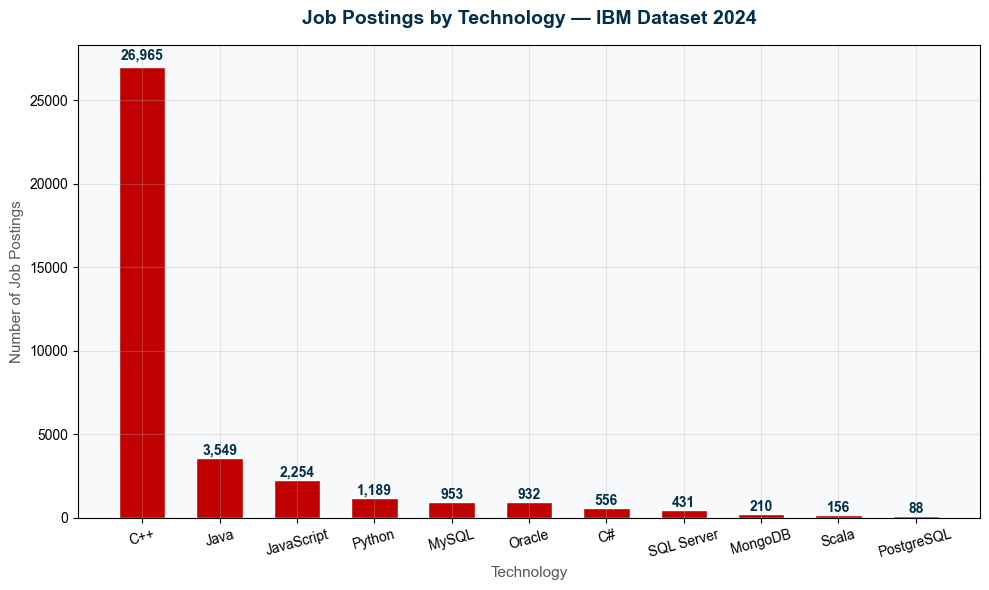

In [49]:
from chart_template import bar_chart

bar_chart(
    data=df_tech_jobs,
    x_col='Technology',
    y_col='Job_Postings',
    title='Job Postings by Technology — IBM Dataset 2024',
    xlabel='Technology',
    ylabel='Number of Job Postings',
    value_fmt='{:,.0f}',
    color='#C00000',
    save_as='../reports/chart_jobs_by_technology.png'
)

In [50]:
print(df_jobs.columns.tolist())

['Id', 'Job Title', 'Job Experience Required', 'Key Skills', 'Role Category', 'Location', 'Functional Area', 'Industry', 'Role']


In [51]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

response = requests.get(url)
print(f"Status code: {response.status_code}")

# Parse the HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Find the table
table = soup.find('table')
df_languages = pd.read_html(str(table))[0]

print(f"Shape: {df_languages.shape}")
print(df_languages.head())

Status code: 200
Shape: (11, 5)
     0           1                             2                      3  \
0  No.    Language                    Created By  Average Annual Salary   
1    1      Python              Guido van Rossum               $114,383   
2    2        Java                 James Gosling               $101,013   
3    3           R  Robert Gentleman, Ross Ihaka                $92,037   
4    4  Javascript                      Netscape               $110,981   

                     4  
0  Learning Difficulty  
1                 Easy  
2                 Easy  
3                 Hard  
4                 Easy  


C:\Users\Jmero\AppData\Local\Temp\ipykernel_13496\1066942076.py:15: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_languages = pd.read_html(str(table))[0]


In [52]:
# Fix column names using first row as header
df_languages.columns = df_languages.iloc[0]
df_languages = df_languages.drop(0).reset_index(drop=True)

# Clean salary column — remove $ and commas, convert to numeric
df_languages['Average Annual Salary'] = (
    df_languages['Average Annual Salary']
    .str.replace('[$,]', '', regex=True)
    .astype(float)
)

print(df_languages[['Language', 'Average Annual Salary']])

0    Language  Average Annual Salary
0      Python               114383.0
1        Java               101013.0
2           R                92037.0
3  Javascript               110981.0
4       Swift               130801.0
5         C++               113865.0
6          C#                88726.0
7         PHP                84727.0
8         SQL                84793.0
9          Go                94082.0


Saved: ../reports/chart_salary_by_language.png


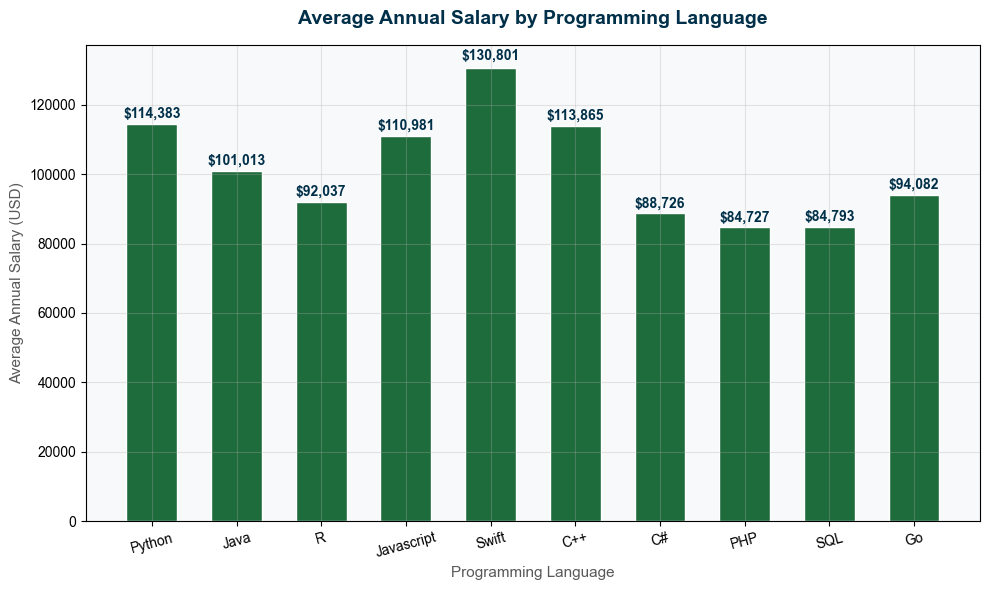

In [53]:
bar_chart(
    data=df_languages,
    x_col='Language',
    y_col='Average Annual Salary',
    title='Average Annual Salary by Programming Language',
    xlabel='Programming Language',
    ylabel='Average Annual Salary (USD)',
    value_fmt='${:,.0f}',
    color='#1E6B3C',
    save_as='../reports/chart_salary_by_language.png'
)